In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

In [2]:
dataset = pd.read_csv("Social_Network_Ads.csv")

dataset.drop(columns=["User ID","Gender"],inplace=True)

In [3]:
dataset.head(3)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0


# *insure that the data has not null value*

In [4]:
dataset.isnull().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


split data

In [5]:
x = dataset.iloc[:,:-1]
y = dataset["Purchased"]

scaling data for better result

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x),columns=x.columns)

# split data into train and test

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.2,random_state=42)

# ***Decision Tree***

decision tree (Classification)

In [10]:
from sklearn.tree import DecisionTreeClassifier

In [11]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

***check our data is overfited or not by help of test score and train score. if test score is much greater or less then train score then our data is overfited.***

In [12]:
dt.score(x_test,y_test)*100

77.1875

In [13]:
dt.score(x_train, y_train)

1.0

***becaue teat score is 79.68 and train score is 1 so that our model is overfited.***

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


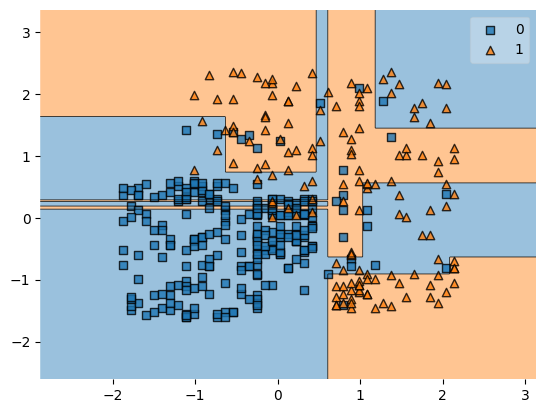

In [22]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=dt)
plt.show()

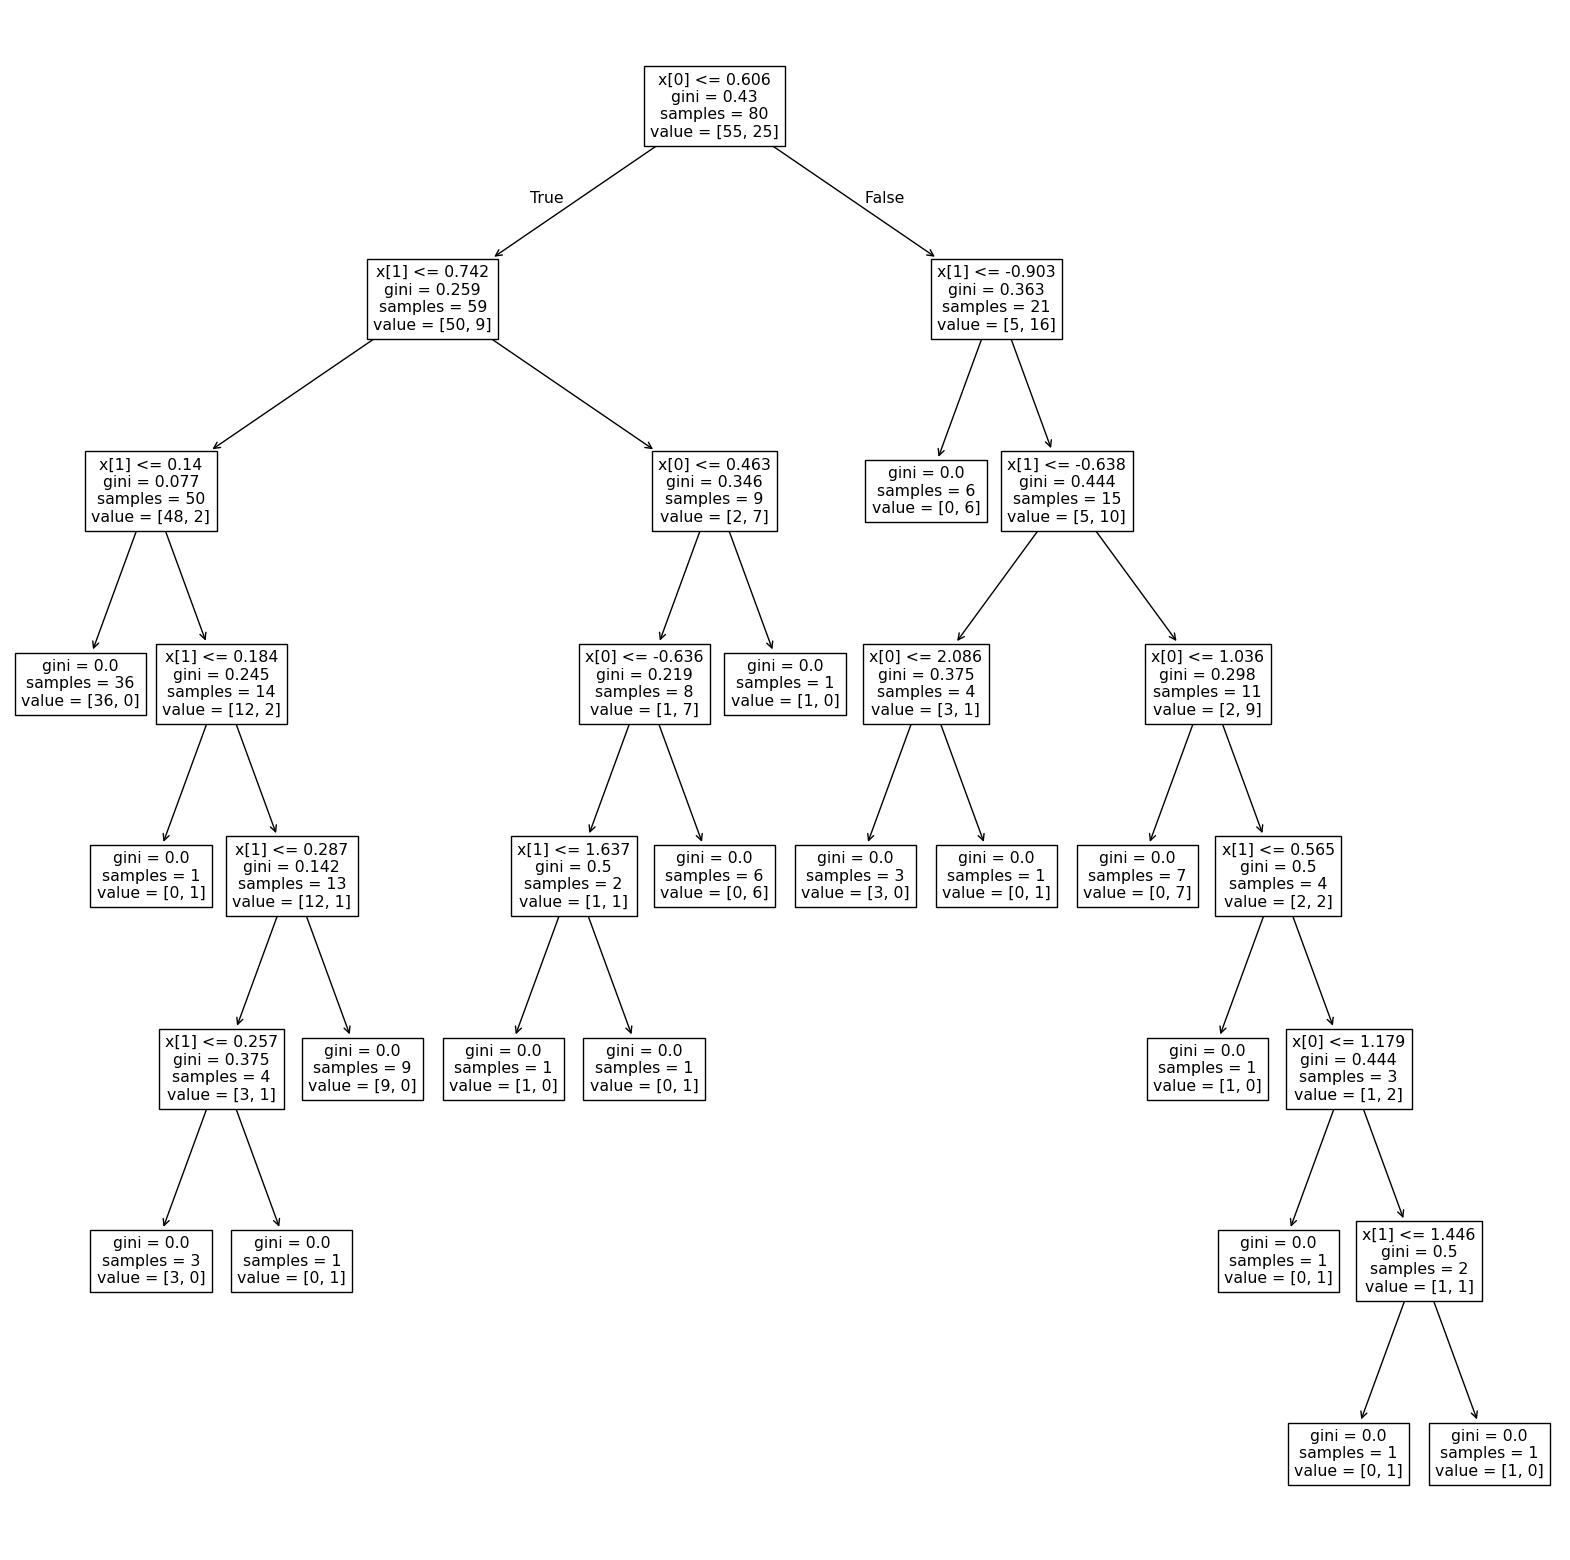

In [23]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,20))
plot_tree(dt)
plt.show()

# ***Pre Pruning***

In [24]:
dt1 = DecisionTreeClassifier(max_depth=3)
dt1.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [25]:
dt1.score(x_test,y_test)*100

89.375

In [26]:
dt1.score(x_train,y_train)*100

92.5

make decision tree

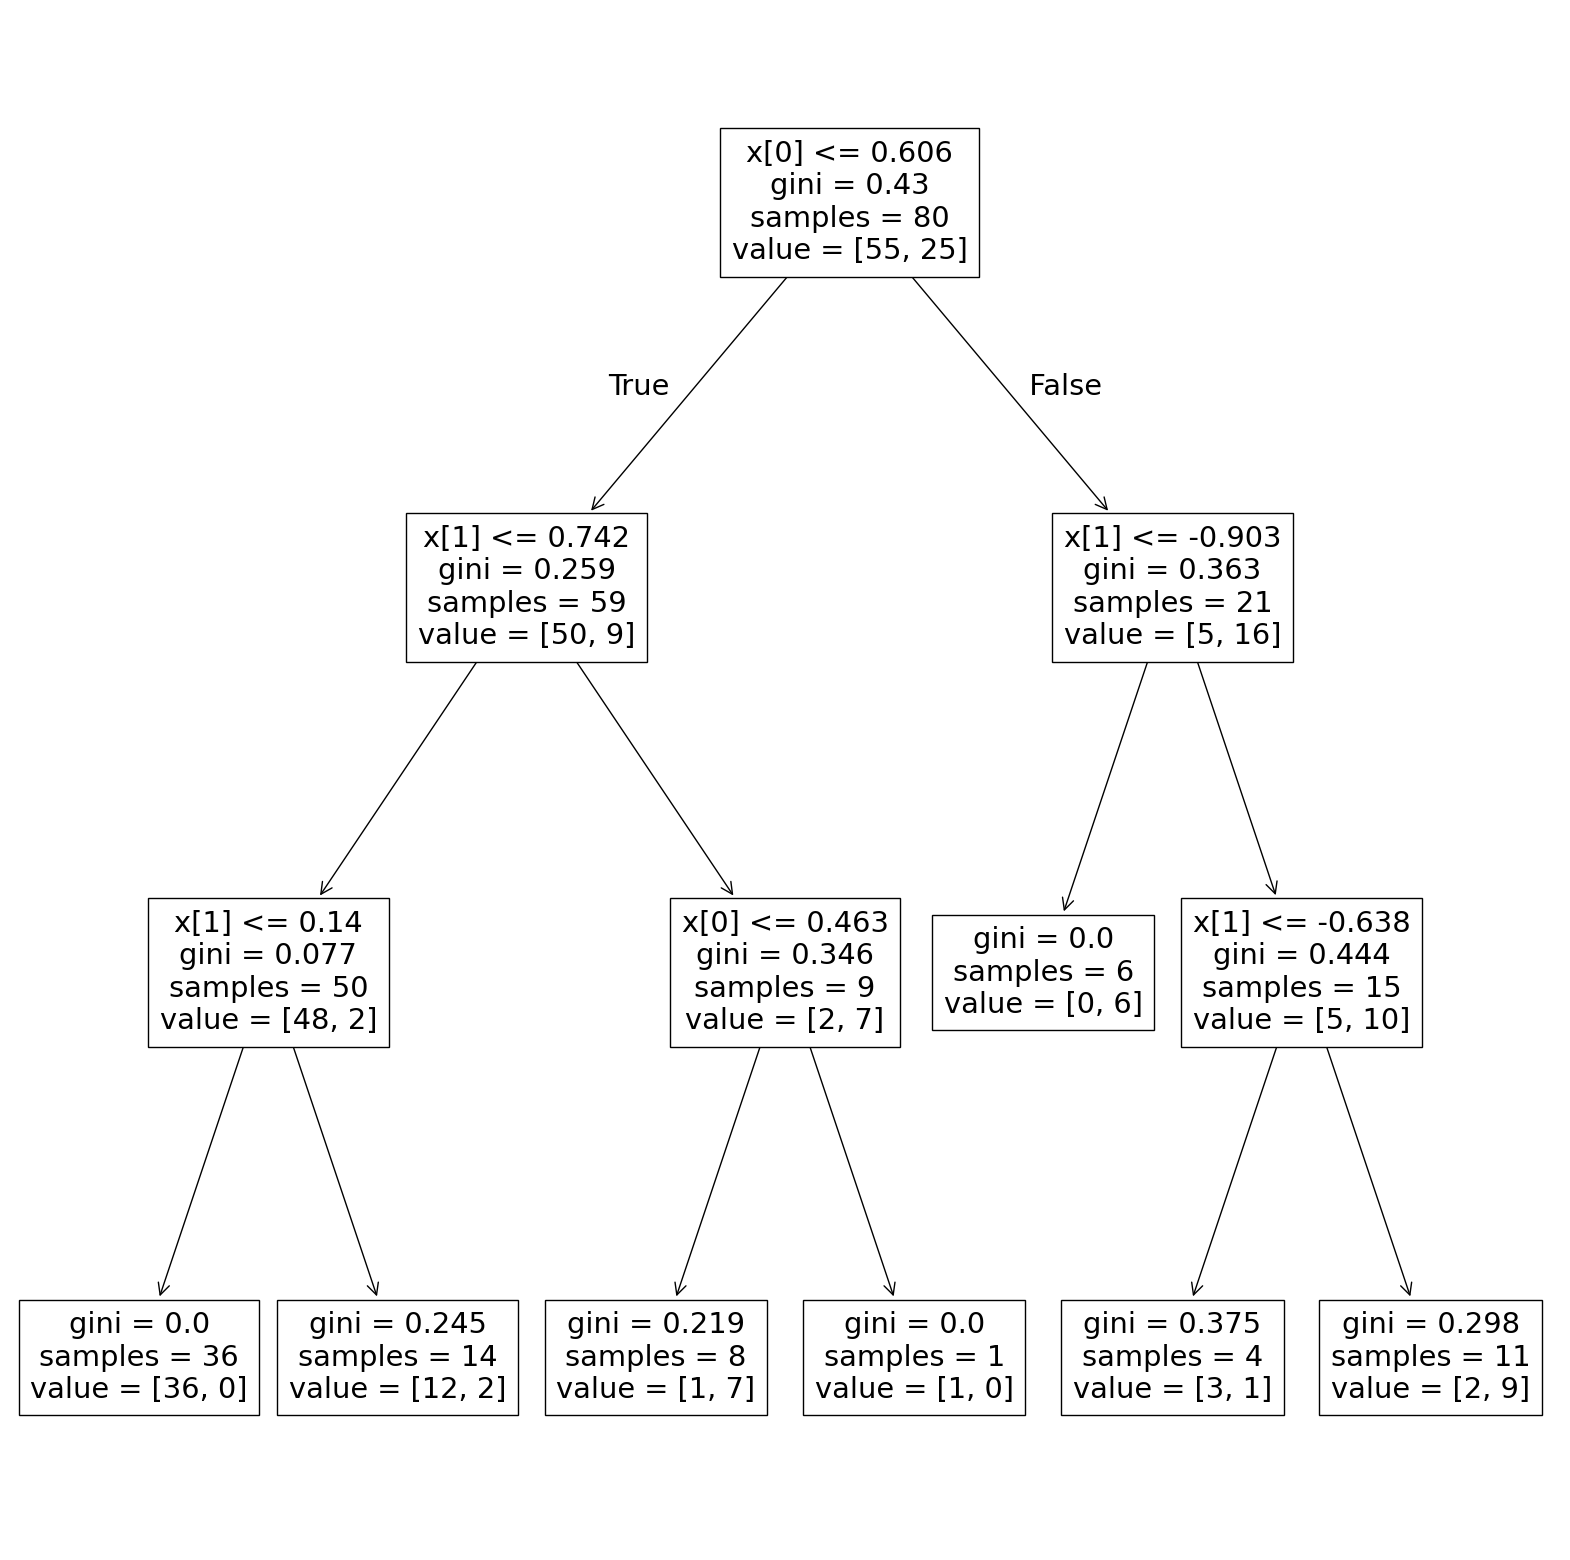

In [27]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,20))
plot_tree(dt1)
plt.show()

# ***post pruning***

In [28]:
for i in range(1,20):
  dt2 = DecisionTreeClassifier(max_depth=i)
  dt2.fit(x_train,y_train)
  print(dt2.score(x_train,y_train),dt2.score(x_test,y_test),i)

0.825 0.840625 1
0.8875 0.915625 2
0.925 0.89375 3
0.95 0.765625 4
0.975 0.828125 5
1.0 0.828125 6
1.0 0.821875 7
1.0 0.821875 8
1.0 0.821875 9
1.0 0.828125 10
1.0 0.790625 11
1.0 0.796875 12
1.0 0.828125 13
1.0 0.790625 14
1.0 0.796875 15
1.0 0.790625 16
1.0 0.828125 17
1.0 0.828125 18
1.0 0.828125 19


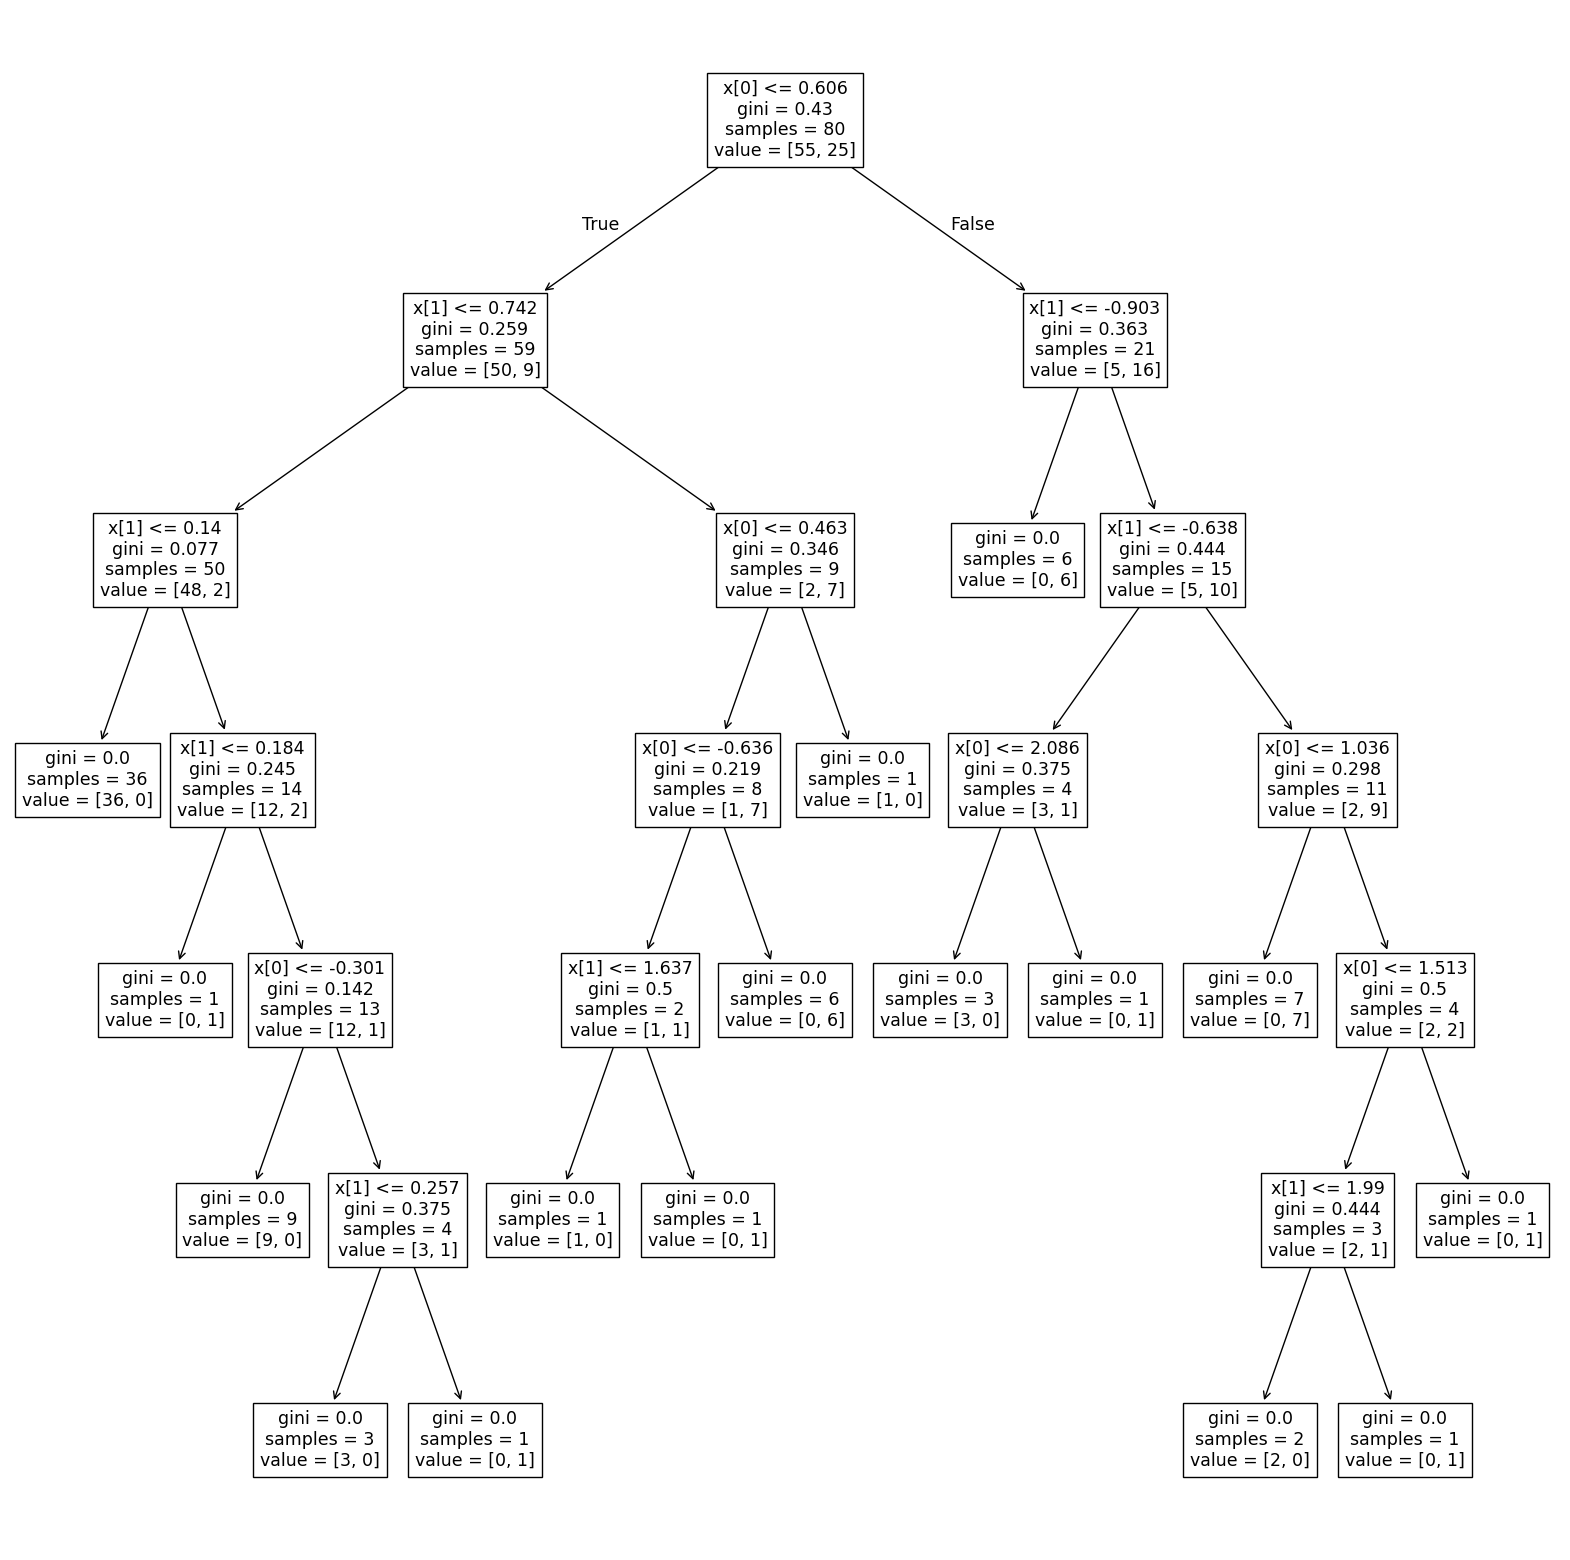

In [29]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,20))
plot_tree(dt2)
plt.show()